#THỰC HÀNH: CÁC GIẢI THUẬT PHÂN LOẠI CƠ BẢN

##GIẢI THUẬT 3: BAYES NGÂY THƠ (NAÏVE BAYES)
###Bài tập thực hành 1: Xây dựng mô hình Naïve ngây thơ trên tập dữ liệu hành vi của khách hàng

###Ngữ cảnh (Context)
Tệp dữ liệu này được sử dụng nhằm áp dụng các thuật toán học máy (machine learning) khác nhau và so sánh kết quả giữa các mô hình, lấy ví dụ từ các khóa học Machine Learning trên Udemy.

-----
###Nội dung (Content)
Bộ dữ liệu bao gồm thông tin chi tiết của khoảng 400 khách hàng của một công ty, bao gồm:
- ID người dùng,
- Giới tính,
-  Tuổi,
- Mức lương ước tính (Estimated Salary).

Ngoài ra, dữ liệu còn thu thập thông tin về quyết định mua hàng – tức là việc khách hàng có mua sản phẩm cụ thể hay không.

🔹 Biến mục tiêu (target): Purchased
🔹 Các đặc trưng (features): User ID, Gender, Age, EstimatedSalary

In [12]:
# import requirement libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import itertools

# for solve problem of show plotly plots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# optional
import warnings
warnings.filterwarnings('ignore')
plt.style.use('_mpl-gallery')

In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [14]:
# import dataset
data = pd.read_csv('/content/drive/MyDrive/Data_Analysis/DA06/Customer_Behaviour.csv')
print(f"shape: {data.shape}")
data.head()

shape: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


###2. Tổng quan về bộ dữ liệu

In [15]:
df = pd.DataFrame(data)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


Dựa trên các thông tin ở trên:
- Có vẻ như không có giá trị bị thiếu trong tập dữ liệu, điều này sẽ được kiểm tra chi tiết hơn ở phần sau.
- Chúng ta có 4 đặc trưng (features) bao gồm: User ID, Gender, Age và EstimatedSalary.
- Biến mục tiêu (target) là Purchased.

Trong tập dữ liệu, chỉ có một biến phân loại (categorical variable) là Gender.

###3. Chuẩn bị dữ liệu

In [17]:
# Check missing value
df.isnull().sum().to_frame('NaN value').T

,User ID,Gender,Age,EstimatedSalary,Purchased
NaN value,0,0,0,0,0


kiểm tra từng cột để phát hiện lỗi cú pháp hoặc giá trị không hợp lệ

In [18]:
# check count of unique values in each columns
for col in df:
    print(f"{col}: {df[col].nunique()}")

User ID: 400
Gender: 2
Age: 43
EstimatedSalary: 117
Purchased: 2


In [19]:
# more details
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [20]:
df.describe(include=[object]).T

,count,unique,top,freq
Gender,400,2,Female,204


Theo các bảng trên:
- Độ tuổi nằm trong khoảng từ 16 đến 60 tuổi.
- Biến mục tiêu (target) bao gồm 2 lớp: 1 và 0.
- Số lượng nam và nữ trong tập dữ liệu gần như bằng nhau.
- Khoảng giá trị của các đặc trưng khác nhau khá lớn, do đó cần chuẩn hóa dữ liệu (standardization).

In [21]:
# Drop User ID columns
df.drop('User ID', axis=1, inplace=True)
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [22]:
# convert categoriacl feature to numerical:
# only Gender is categorical
df['Gender'] = df['Gender'].replace(['Male', 'Female'], [0, 1])
df

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0
...,...,...,...,...
395,1,46,41000,1
396,0,51,23000,1
397,1,50,20000,1
398,0,36,33000,0


Bây giờ hãy kiểm tra tập dữ liệu lần cuối


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           400 non-null    int64
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [28]:
df.isna().sum()

,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


###4. Phân tích dữ liệu thăm dò

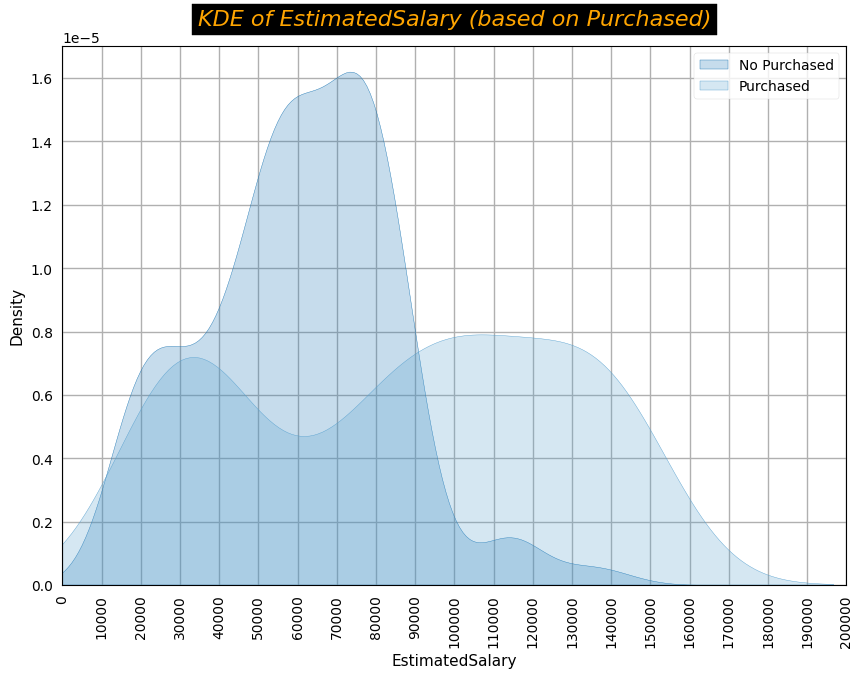

In [30]:
# check distribution of EstimatedSalary (based on Purchased)
font = {'fontsize':16, 'fontstyle':'italic', 'backgroundcolor':'black', 'color':'orange'}
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Purchased'] == 0, 'EstimatedSalary'], label='No Purchased', shade=True)
sns.kdeplot(df.loc[df['Purchased'] == 1, 'EstimatedSalary'], label='Purchased', shade=True)
plt.title('KDE of EstimatedSalary (based on Purchased)', fontdict=font, pad=15)
plt.xticks(np.arange(0,200001,10000), rotation=90)
plt.xlim([0,200001])
plt.legend()
plt.show()

**Nhận xét:** Biểu đồ thể hiện phân bố độ tuổi của khách hàng theo trạng thái mua hàng (Purchased và No Purchased).

Có thể thấy:
- Nhóm không mua hàng (No Purchased) tập trung chủ yếu ở độ tuổi 20–40, với mật độ cao nhất khoảng 30 tuổi.
- Nhóm mua hàng (Purchased) lại tập trung nhiều hơn ở độ tuổi 40–60, với đỉnh rõ ràng quanh 45–50 tuổi.

Điều này cho thấy tuổi tác có ảnh hưởng đến hành vi mua hàng — những khách hàng lớn tuổi hơn có xu hướng mua sản phẩm nhiều hơn.

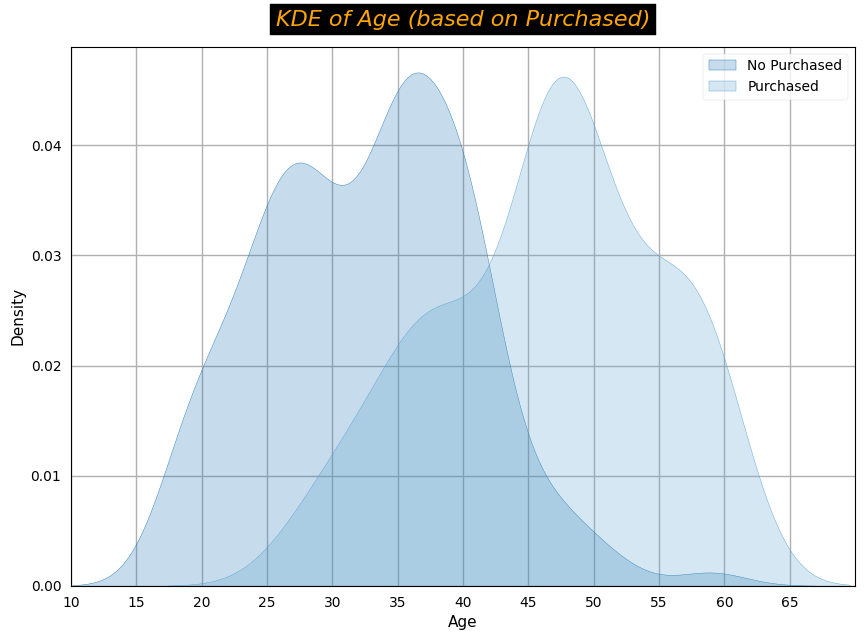

In [38]:
# check distribution of Purchased (based on Purchased)
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Purchased'] == 0, 'Age'], label='No Purchased', shade=True)
sns.kdeplot(df.loc[df['Purchased'] == 1, 'Age'], label='Purchased', shade=True)
plt.title('KDE of Age (based on Purchased)', fontdict=font, pad=15)
plt.xticks(np.arange(0,70,5))
plt.xlim([10,70])
plt.legend()
plt.show()

**Nhận xét:** Biểu đồ thể hiện phân bố mức lương ước tính (EstimatedSalary) của khách hàng theo trạng thái mua hàng.

Kết quả cho thấy:
- Nhóm không mua hàng có xu hướng tập trung ở mức lương thấp hơn (dưới 80.000).
- Ngược lại, nhóm mua hàng có phân bố lệch sang mức lương cao hơn, thường từ 60.000 đến 150.000.

Điều này gợi ý rằng mức thu nhập cao có thể liên quan đến khả năng mua hàng cao hơn.

In [42]:
# define x (features) and y (target)
x = np.asanyarray(df2.drop('Purchased', axis=1))
y = df2.Purchased.values.reshape(-1,1)

In [41]:
# standardize EstimatedSalary and Age with StandardScaler
df2 = df.copy()
scaler = MinMaxScaler(feature_range=(18,60)).fit(df[['EstimatedSalary']])
df2['EstimatedSalary'] = scaler.transform(df2['EstimatedSalary'].values.reshape(-1,1))

# define x (features) and y (target)
x = np.asanyarray(df2.drop('Purchased', axis=1))
y = df2.Purchased.values.reshape(-1,1)

-------------------- Shape --------------------
x_train: (320, 3)
y_train: (320, 1)
x_test: (80, 3)
y_test: (80, 1)


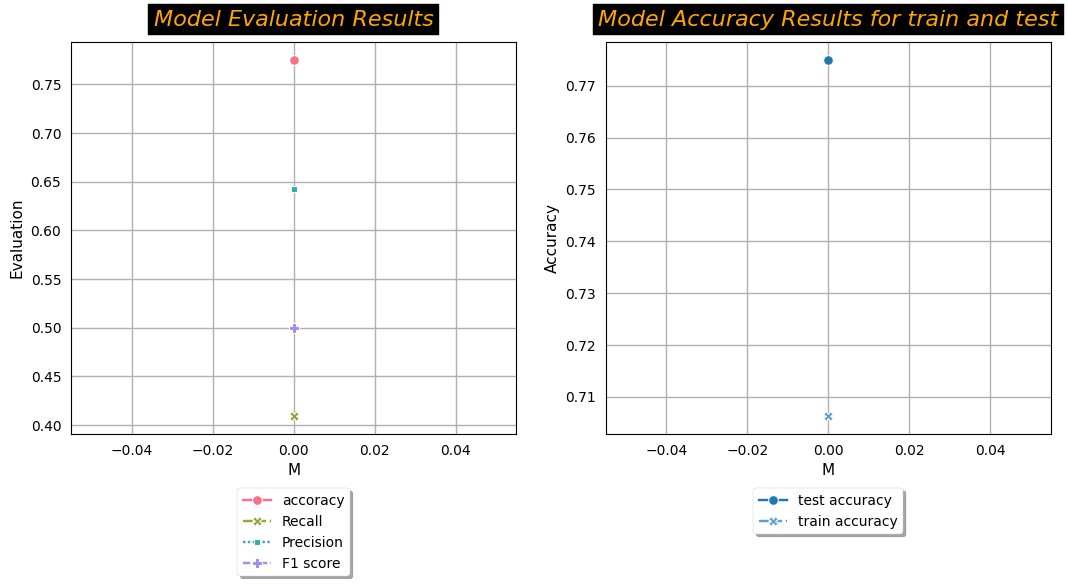

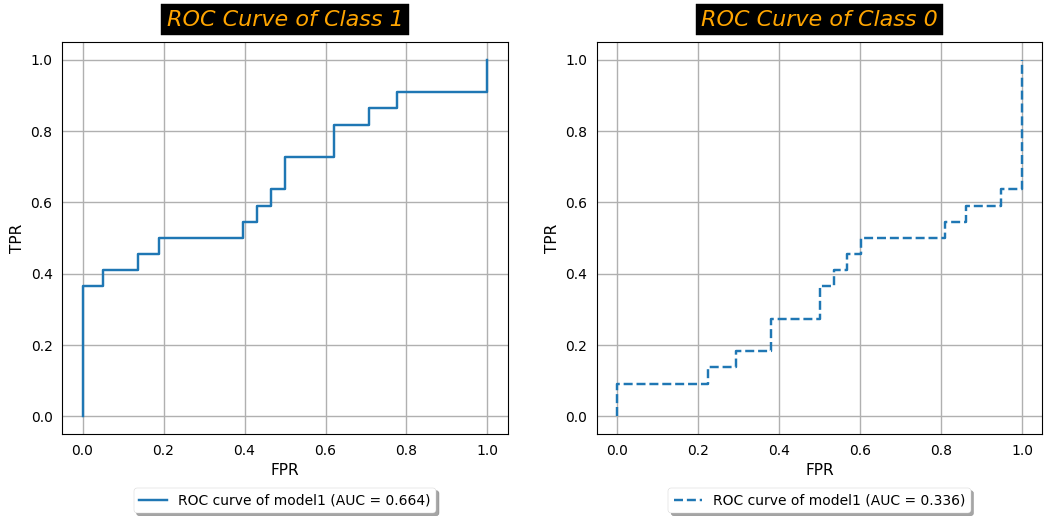

-------------------- Confusion Matrix --------------------
[[53  5]
 [13  9]]


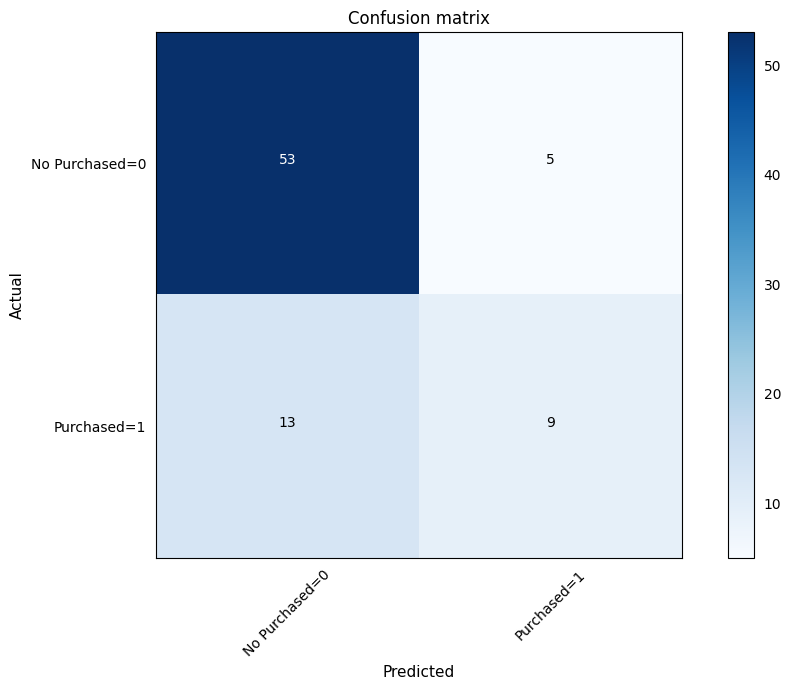

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.80      0.91      0.85        58
   Purchased=1       0.64      0.41      0.50        22

      accuracy                           0.78        80
     macro avg       0.72      0.66      0.68        80
  weighted avg       0.76      0.78      0.76        80
 

Jaccard Score: 0.3333333333333333 



In [43]:
# Now create first model
clf1, acc_test1, acc_train1 = modeling(x, y, 0.2, ['No Purchased=0', 'Purchased=1'])

-------------------- Shape --------------------
x_train: (320, 3)
y_train: (320, 1)
x_test: (80, 3)
y_test: (80, 1)


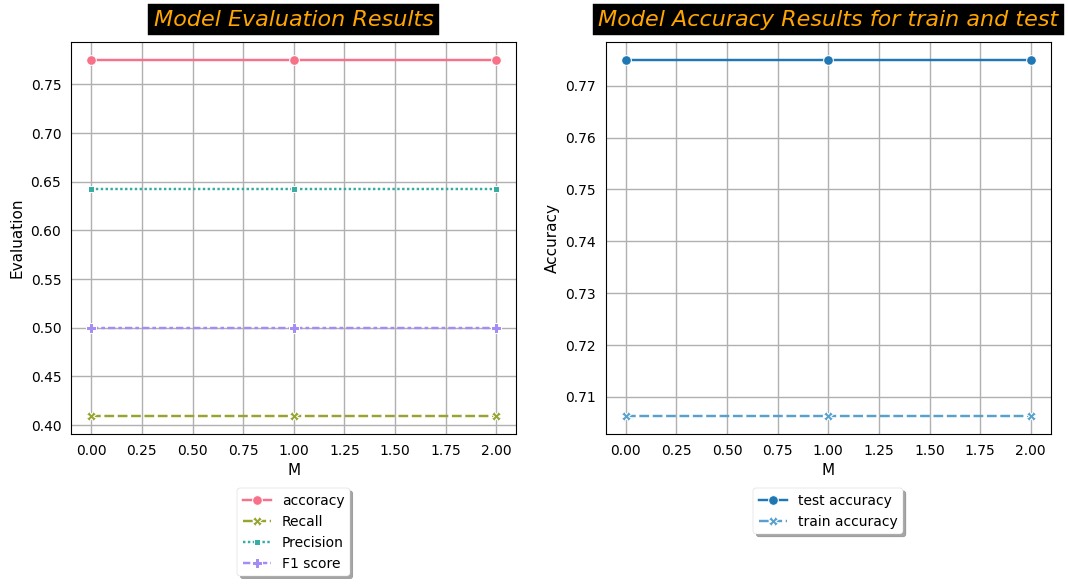

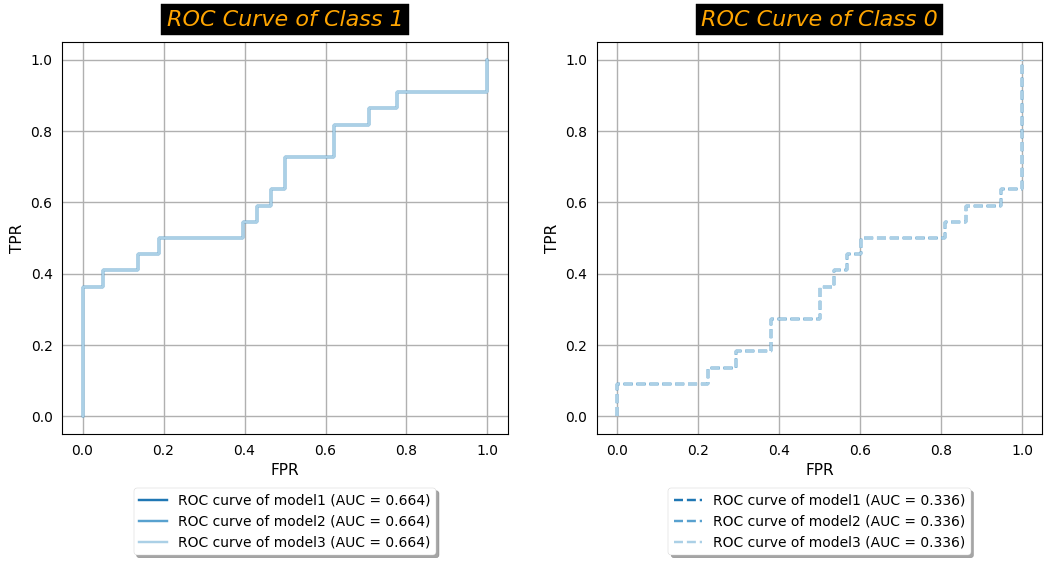

-------------------- Confusion Matrix --------------------
[[53  5]
 [13  9]]


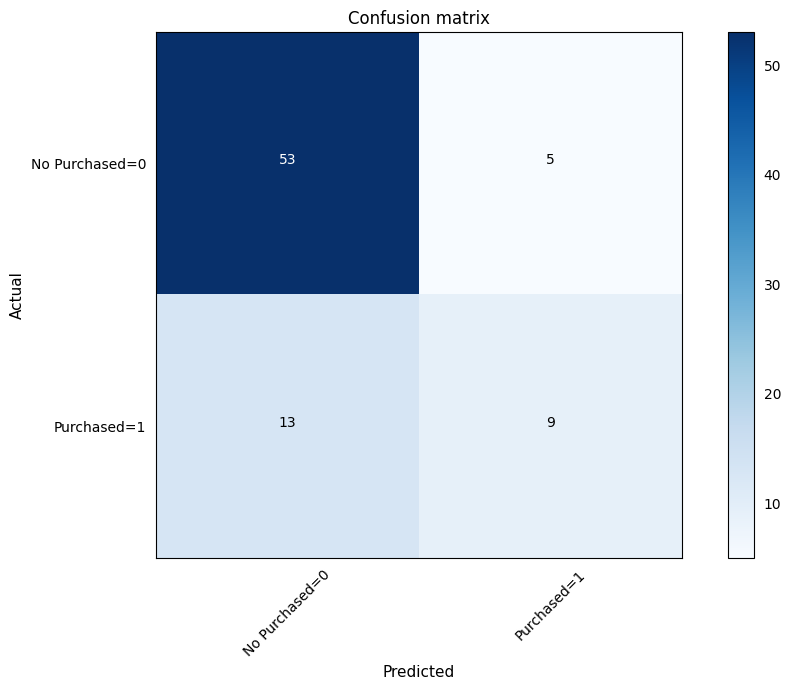

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.80      0.91      0.85        58
   Purchased=1       0.64      0.41      0.50        22

      accuracy                           0.78        80
     macro avg       0.72      0.66      0.68        80
  weighted avg       0.76      0.78      0.76        80
 

Jaccard Score: 0.3333333333333333 



In [48]:
# define x (features) and y (target)
x = np.asanyarray(df2.drop('Purchased', axis=1))
y = df2.Purchased.values.reshape(-1,1)

# Now create first model
clf1, acc_test1, acc_train1 = modeling(x, y, 0.2, ['No Purchased=0', 'Purchased=1'])

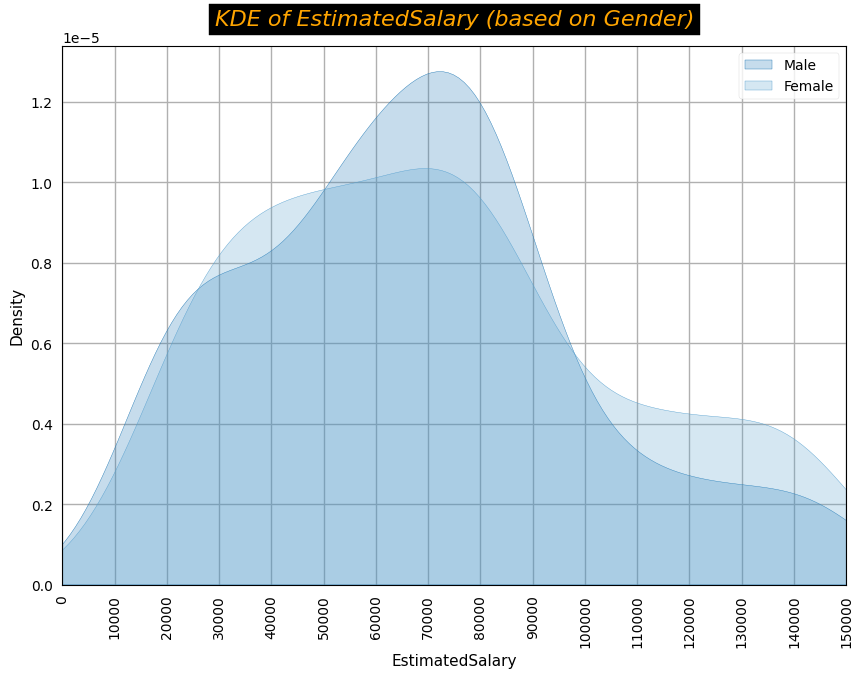

In [46]:
# check distribution of EstimatedSalary (based on Gender)
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Gender'] == 0, 'EstimatedSalary'], label='Male', shade=True)
sns.kdeplot(df.loc[df['Gender'] == 1, 'EstimatedSalary'], label='Female', shade=True)
plt.title('KDE of EstimatedSalary (based on Gender)', fontdict=font, pad=15)
plt.xticks(np.arange(0,150001,10000), rotation=90)
plt.xlim([0,150001])
plt.legend()
plt.show()

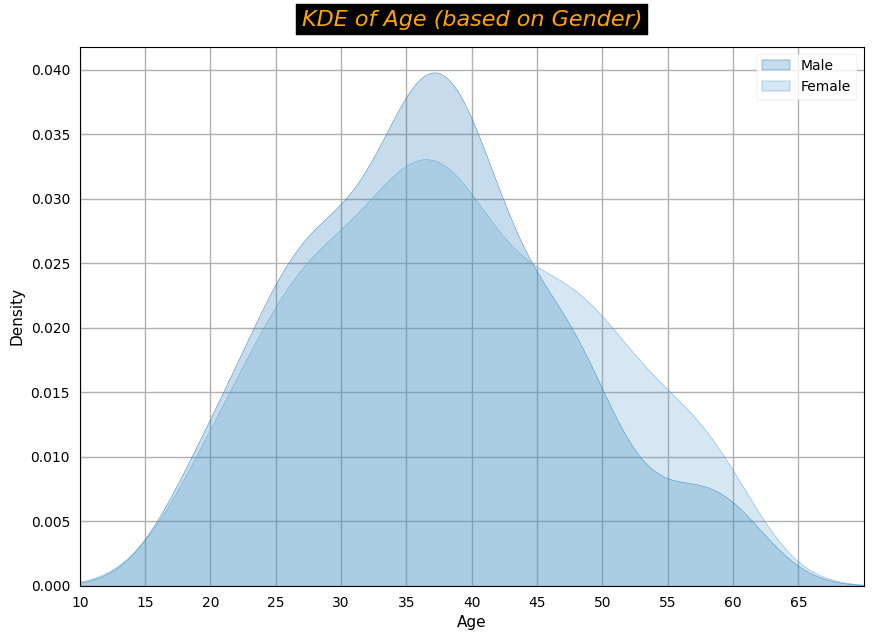

In [50]:
# check distribution of Age (based on Gender)
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Gender'] == 0, 'Age'], label='Male', shade=True)
sns.kdeplot(df.loc[df['Gender'] == 1, 'Age'], label='Female', shade=True)
plt.title('KDE of Age (based on Gender)', fontdict=font, pad=15)
plt.xticks(np.arange(0,70,5))
plt.xlim([10,70])
plt.legend()
plt.show()

Dựa trên các biểu đồ KDE ở trên:
- Hầu hết những người có thu nhập trong khoảng 40.000 đến 90.000 không quyết định mua sản phẩm.
- Phần lớn những người quyết định mua sản phẩm đều lớn tuổi hơn so với những người không mua.
- Những người trên 43 tuổi thường có xu hướng quan tâm đến việc mua sản phẩm.
- Dựa trên giới tính (nam hoặc nữ), phân bố KDE gần như tương tự nhau, không có sự khác biệt đáng kể

###4.1. Phân tích đơn biến

In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,400.0,0.5100,0.500526,0.0,0.00,1.0,1.0,1.0
Age,400.0,37.6550,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,69742.5000,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,0.3575,0.479864,0.0,0.00,0.0,1.0,1.0


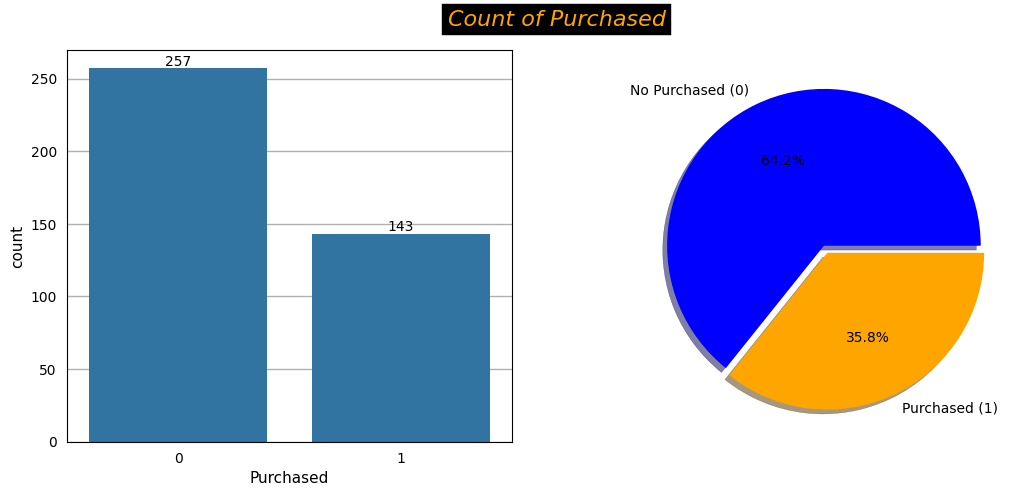

In [52]:
# count based on Purchased (countplot)
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.countplot(data=df, x='Purchased', ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container)

# count based on Purchased (pie chart)
slices = df.Purchased.value_counts().values
activities = ['No Purchased (0)', 'Purchased (1)']
axes[1].pie(slices, labels=activities, colors=['blue','orange'], shadow=True, explode=[0,0.05], autopct='%1.1f%%')

plt.suptitle('Count of Purchased', y=1.09, **font)
plt.show()

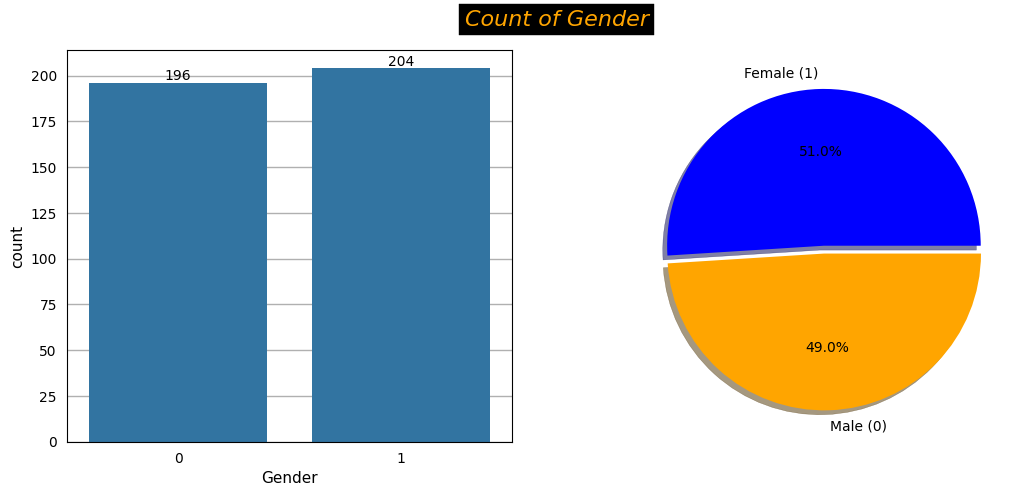

In [53]:
# count based on Gender (countplot)
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.countplot(data=df, x='Gender', ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container)

# count based on Gender (pie chart)
slices = df.Gender.value_counts().values
activities = ['Female (1)', 'Male (0)']
axes[1].pie(slices, labels=activities, colors=['blue','orange'], shadow=True, explode=[0,0.05], autopct='%1.1f%%')

plt.suptitle('Count of Gender', y=1.09, **font)
plt.show()

Dựa trên các biểu đồ và bảng ở trên:

- Số lượng nam và nữ trong tập dữ liệu gần như bằng nhau.
- Số người quyết định mua sản phẩm ít hơn số người không mua sản phẩm.

###4.2. Phân tích hai biến (Bivariate Analysis)


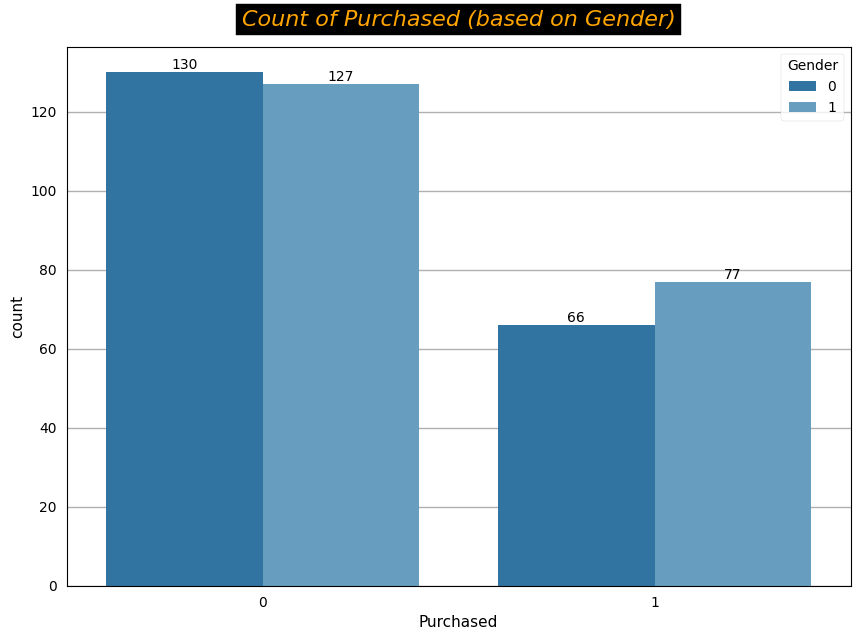

In [54]:
# count of purchased based on Gender
%matplotlib inline
ax = sns.countplot(data=df, x='Purchased', hue='Gender')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count of Purchased (based on Gender)', fontdict=font, pad=15)
plt.show()

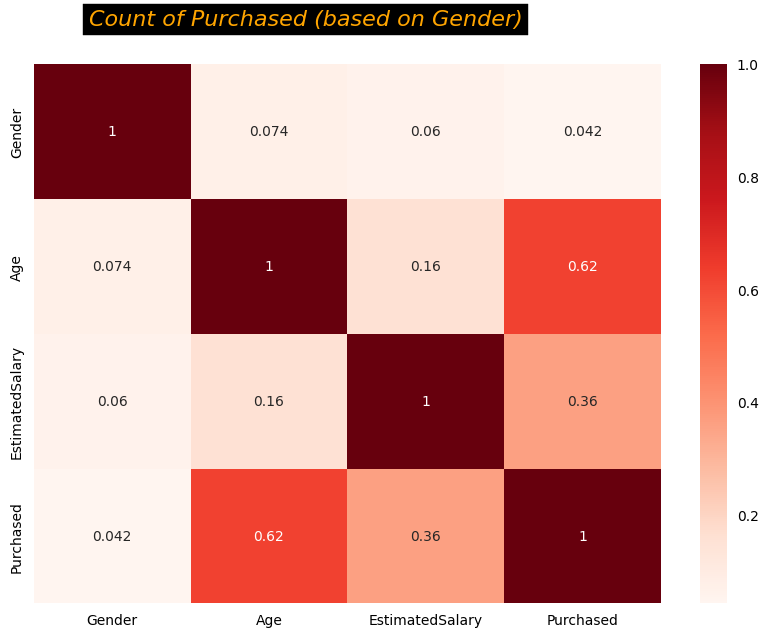

In [55]:
# heatmap
sns.heatmap(df.corr(), cmap='Reds', annot=True)
plt.suptitle('Count of Purchased (based on Gender)', y=1.09, x=0.35, **font)
plt.show()

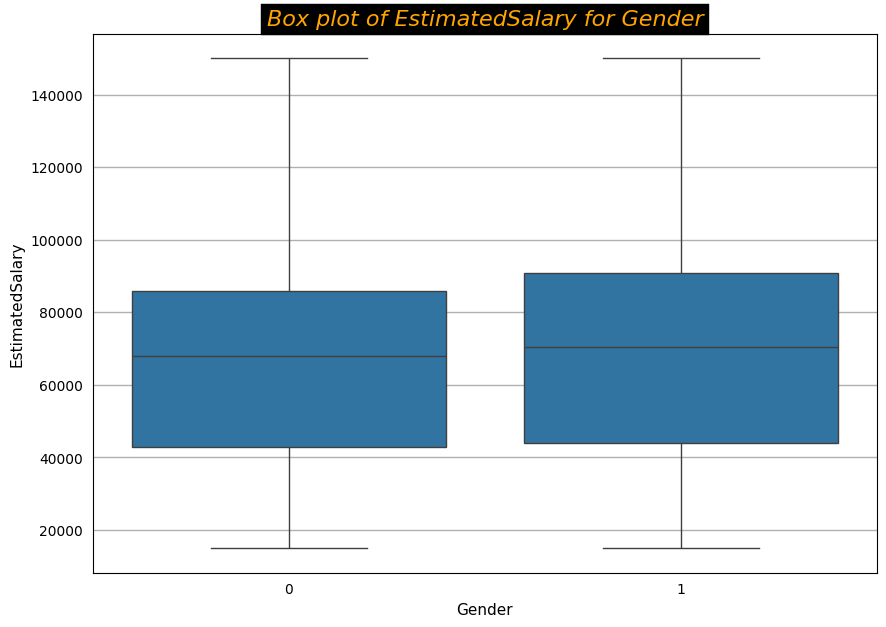

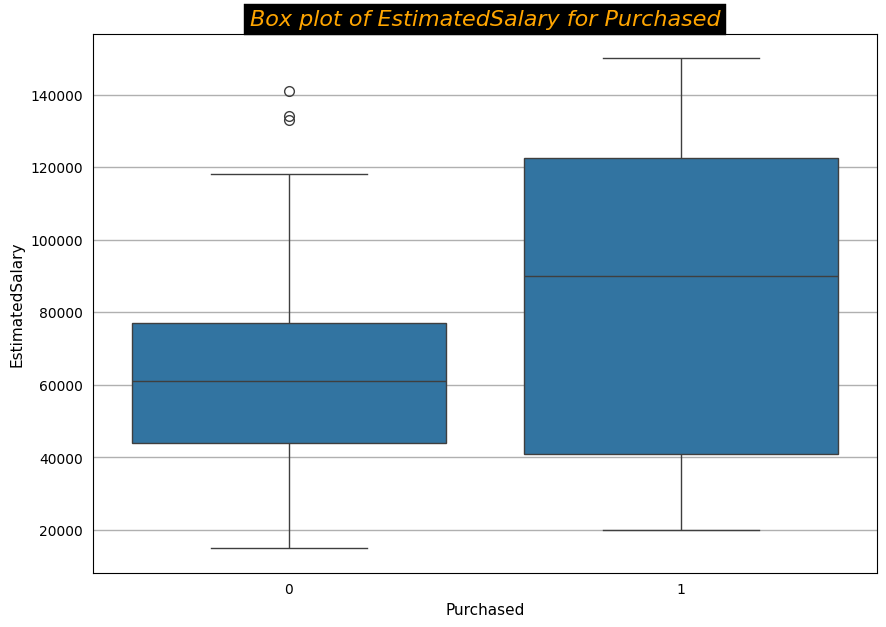

In [56]:
# draw box plot of Estimated salary for male(0) or female(1) Gender
# draw box plot of Estimated salary for no purchased(0) or purchased(1)
for col in ['Gender', 'Purchased']:
    sns.boxplot(data=df, x=col, y='EstimatedSalary')
    plt.title(f'Box plot of EstimatedSalary for {col}', fontdict=font)
    plt.show()

Dựa trên các biểu đồ ở trên:
- Trong nhóm những người quyết định mua sản phẩm, nữ nhiều hơn nam; ngược lại, trong nhóm không mua sản phẩm, nam lại nhiều hơn nữ.
- Mối tương quan cao nhất là giữa Purchased (quyết định mua) và Age (tuổi), với hệ số tương quan 0.62.
- Mức lương ước tính trung bình (EstimatedSalary) của những người quyết định mua sản phẩm cao hơn so với những người không mua.
- Mức lương trung bình giữa nam và nữ gần như không có sự khác biệt đáng kể.

###4.3. Phân tích đa biến (Multivariate Analysis)

Chúng ta sử dụng biểu đồ phân tán (scatter plot) để phân tích các dữ liệu có dạng số học (numerical data).

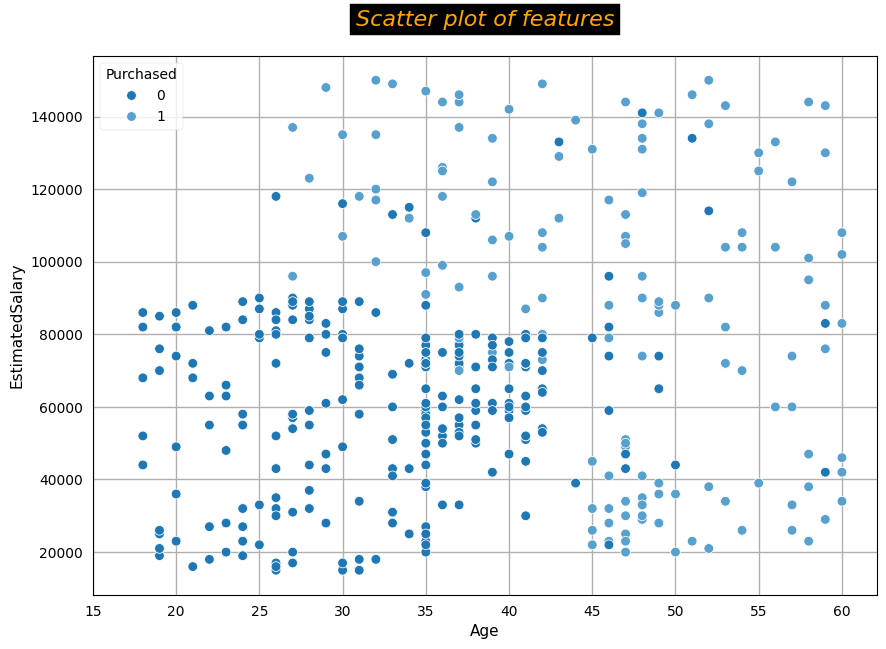

In [57]:
%matplotlib inline
# check feature correlation
sns.scatterplot(data=df,x='Age', y='EstimatedSalary', hue='Purchased',)
plt.title('Scatter plot of features', y=1.04, fontdict=font)
plt.xticks(np.arange(15,65,5))
plt.show()

Để có cái nhìn tốt hơn, chúng ta vẽ một biểu đồ phân tán 3D

In [83]:
# Import thư viện cần thiết
import plotly.express as px
import plotly.io as pio

# Thiết lập renderer hiển thị (rất quan trọng để hiện biểu đồ trong Colab hoặc Jupyter)
pio.renderers.default = "colab"   # Nếu bạn dùng Jupyter Notebook thì đổi thành "notebook_connected"

# Vẽ biểu đồ 3D scatter
fig = px.scatter_3d(
    data_frame=df,
    x='Age',
    y='EstimatedSalary',
    z='Gender',
    color='Purchased',
    template='ggplot2',
    opacity=0.6,
    height=700,
    title='3D Scatter based on Age, EstimatedSalary, Gender and Purchased'
)

# Hiển thị biểu đồ
fig.show()


In [59]:
# check mean of EstimatedSalary based on Gender and Purchased
results = pd.pivot_table(data=df, index='Purchased', columns='Gender', values='EstimatedSalary')
results.style.background_gradient(cmap='summer_r')

Gender,0,1
Purchased,,
0,59630.769231,61480.314961
1,83424.242424,88714.285714


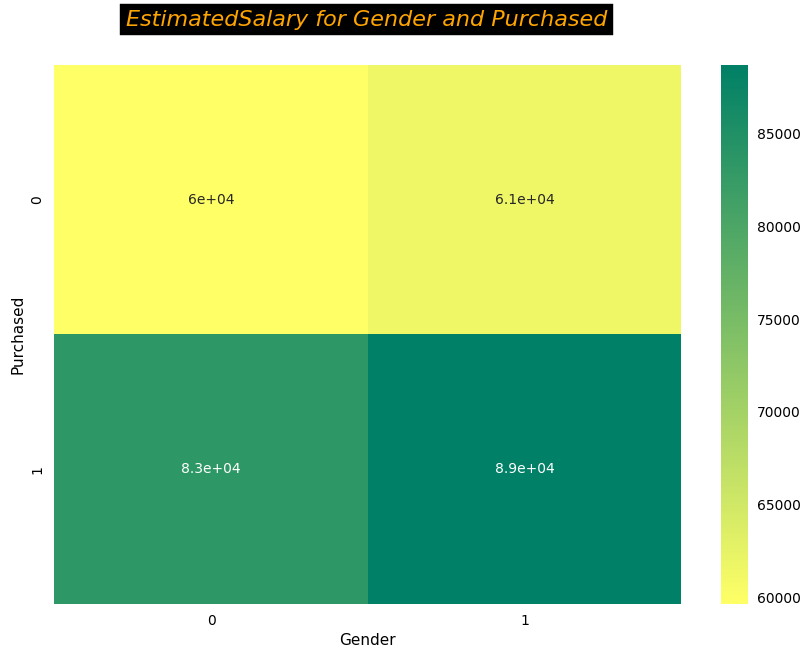

In [60]:
# show result in heatmap
sns.heatmap(results, cmap='summer_r', annot=True)
plt.suptitle('EstimatedSalary for Gender and Purchased', y=1.09, x=0.4, **font)
plt.show()

In [61]:
# check mean of Age based on Gender and Purchased
results = pd.pivot_table(data=df, index='Purchased', columns='Gender', values='Age')
results.style.background_gradient(cmap='summer_r')

Gender,0,1
Purchased,,
0,32.484615,33.110236
1,45.500000,47.155844


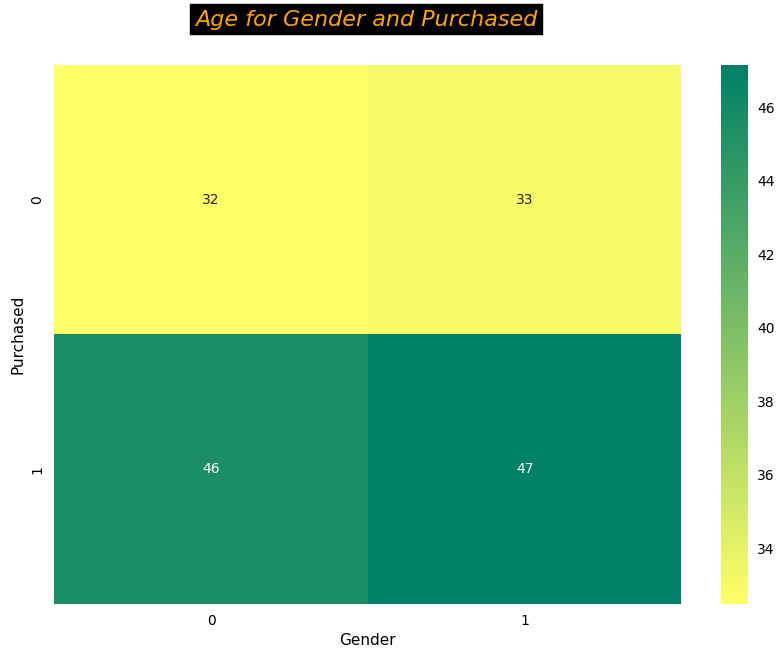

In [62]:
# show result in heatmap
sns.heatmap(results, cmap='summer_r', annot=True)
plt.suptitle('Age for Gender and Purchased', y=1.09, x=0.4, **font)
plt.show()

Dựa trên các biểu đồ ở trên:
- Những người trẻ tuổi và có thu nhập ước tính thấp (EstimatedSalary) thường không quyết định mua sản phẩm.
- Những người có thu nhập ước tính trên 100.000, bất kể độ tuổi, thường có xu hướng mua sản phẩm.
- Những người trên 45 tuổi, dù mức thu nhập thế nào, vẫn có khả năng cao hơn trong việc mua sản phẩm.

###5. Mô hình (Model)

In [63]:
# Our dataset we use for modeling
df

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0
...,...,...,...,...
395,1,46,41000,1
396,0,51,23000,1
397,1,50,20000,1
398,0,36,33000,0


Như bạn có thể thấy, trong tập dữ liệu này có cả dữ liệu rời rạc (discrete) và dữ liệu liên tục (continuous). Vì vậy, trong các loại mô hình Naive Bayes, ta sử dụng Multinomial Naive Bayes.

Tuy nhiên, do phạm vi của các đặc trưng (features) rất khác nhau, như đã đề cập trước đó, nên chúng cần được chuẩn hóa (standardized) trước khi đưa vào mô hình.

In [64]:
# standardize EstimatedSalary and Age with StandardScaler
df2 = df.copy()
scaler = MinMaxScaler(feature_range=(18,60)).fit(df[['EstimatedSalary']])
df2['EstimatedSalary'] = scaler.transform(df2['EstimatedSalary'].values.reshape(-1,1))
df2

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19.244444,0
1,0,35,19.555556,0
2,1,26,26.711111,0
3,1,27,31.066667,0
4,0,19,36.977778,0
...,...,...,...,...
395,1,46,26.088889,1
396,0,51,20.488889,1
397,1,50,19.555556,1
398,0,36,23.600000,0


In [65]:
# define x (features) and y (target)
x = np.asanyarray(df2.drop('Purchased', axis=1))
y = df2.Purchased.values.reshape(-1,1)

In [66]:
FPR1 = []
TPR1 = []
FPR0 = []
TPR0 = []
ACC_test = []
ACC_train = []
Recall = []
Precision = []
F1 = []

def plot_confusion_matrix2(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function plots the confusion matrix.
        cm(array): confusion matrix
        classes(dictionary): classes in our target
    """
    plt.figure(figsize=(10,7))
    plt.grid(False)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt ='d'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")


    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------------------------------------

def Perform_cross_val(model, k, x, y, scoring):
    """
    perform cross validation
        model: logistic model
        k(scaler): the value for n_splits in KFold()
        x(DataFrame or array):  x_train
        y(DataFrame or array): y_train
        scoring(string): an approach for evaluation in cross validation
    """

    kf = KFold(n_splits=k)
    cv_results = cross_val_score(model, x, y, cv=kf, scoring=scoring)
    cv_mean = np.mean(cv_results)
    print('-'*20, f"CV for k={k}, scoring={scoring}", '-'*20)
    print(f"CV mean: {cv_mean}")
    print(f"CV results: {cv_results}\n")

# --------------------------------------------------------------------------------------

def find_fold_index(k, x):
    """
    Find fold index in kfold
        k(scaler): the value used for n_splits in KFold()
        x(DataFrame or array): x_train
    """

    my_fold_index = []
    j=1
    for _ , test in KFold(k).split(x):

        my_fold_index = []
        for i in test:
            my_fold_index.append(i)
        print(f"fold {j}: [{my_fold_index[0]},{my_fold_index[-1]}]")
        print(20*'-')
        j += 1

# --------------------------------------------------------------------------------------

def plot_results(FPR0, TPR0, FPR1, TPR1, ACC_test, ACC_train, Recall, Precision, F1):
    """
    draw ROC curve and plot of Recall, precision, f1 score etc.
        FPR0(list): list of False Positive Rate for class 0
        TPR0(list): list of True Positive Rate for class 0
        FPR1(list): list of Flase Positive Rate for class 1
        TPR1(list): list of True Positive Rate for class 1
        ACC(list): list of accuracy of models
        Recall(list): list of recall score of models
        Precision(list): list of Precision score of models
        F1(list): list of F1 score of models
    """
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    # plot model evaluation
    ax[0].set_title('Model Evaluation Results', fontdict=font, y=1.02)
    sns.lineplot(data=pd.DataFrame({'accoracy': ACC_test, 'Recall': Recall,
                                    'Precision': Precision, 'F1 score': F1}),
                                    markers=True, ax=ax[0])
    ax[0].set_xlabel('M')
    ax[0].set_ylabel('Evaluation')
    ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True)

    # plot model evaluation
    ax[1].set_title('Model Accuracy Results for train and test', fontdict=font, y=1.02)
    sns.lineplot(data=pd.DataFrame({'test accuracy': ACC_test, 'train accuracy': ACC_train}),
                                    markers=True, ax=ax[1])
    ax[1].set_xlabel('M')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True)
    plt.show()

    # plot ROC curve for class 1
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    i=1
    ax[0].set_title('ROC Curve of Class 1', fontdict=font, y=1.02)
    for fpr , tpr in zip(FPR1, TPR1):
        ax[0].plot(fpr, tpr, label=f"ROC curve of model{i} (AUC = {round(metrics.auc(fpr, tpr),3)})")
        i += 1
        ax[0].set_xlabel('FPR')
        ax[0].set_ylabel('TPR')
    ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True)

    # plot ROC curve for class zero
    i=1
    ax[1].set_title('ROC Curve of Class 0', fontdict=font, y=1.02)
    for fpr , tpr in zip(FPR0, TPR0):
        ax[1].plot(fpr, tpr, '--', label=f"ROC curve of model{i} (AUC = {round(metrics.auc(fpr, tpr),3)})")
        i += 1
        ax[1].set_xlabel('FPR')
        ax[1].set_ylabel('TPR')
    ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
        fancybox=True, shadow=True)

    plt.show()

# --------------------------------------------------------------------------------------

def modeling(x, y, test_size, classes, is_add=1 ):

    # split data to train and test
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=0)
    print(20*'-', 'Shape', 20*'-')
    print(f"x_train: {x_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"x_test: {x_test.shape}")
    print(f"y_test: {y_test.shape}")



    # define model and fit model
    clf = MultinomialNB()
    clf.fit(x_train, y_train.ravel())

    # prediction and results
    y_pred_train = clf.predict(x_train)
    y_pred_test = clf.predict(x_test)
    y_proba_train = clf.predict_proba(x_train)
    y_proba_test = clf.predict_proba(x_test)

    cm = metrics.confusion_matrix(y_test, y_pred_test)
    fpr1, tpr1, _ = metrics.roc_curve(y_test, y_proba_test[:,1])
    fpr0, tpr0, _ = metrics.roc_curve(y_test, y_proba_test[:,0])
    acc_test = metrics.accuracy_score(y_test, y_pred_test)
    acc_train = metrics.accuracy_score(y_train, y_pred_train)
    rec = metrics.recall_score(y_test, y_pred_test)
    pre = metrics.precision_score(y_test, y_pred_test)
    f1 = metrics.f1_score(y_test, y_pred_test)

    # append results
    if is_add == 1:
        FPR0.append(fpr0)
        TPR0.append(tpr0)
        FPR1.append(fpr1)
        TPR1.append(tpr1)
        ACC_test.append(acc_test)
        ACC_train.append(acc_train)
        Recall.append(rec)
        Precision.append(pre)
        F1.append(f1)

    plot_results(FPR0, TPR0, FPR1, TPR1, ACC_test, ACC_train, Recall, Precision, F1)

    # Evaluation model
    print('-'*20 , 'Confusion Matrix', '-'*20)
    print(cm)
    plot_confusion_matrix2(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues)
    # or use plot_confusion_matrix from sklearn.metrics
    print('-'*20 , 'Classification Report', '-'*20)
    print(metrics.classification_report(y_test, y_pred_test, target_names=classes), '\n')
    print(f"Jaccard Score: {metrics.jaccard_score(y_test, y_pred_test)}", '\n')

    # print other result about predicted data
    return clf, acc_test, acc_train

-------------------- Shape --------------------
x_train: (320, 3)
y_train: (320, 1)
x_test: (80, 3)
y_test: (80, 1)


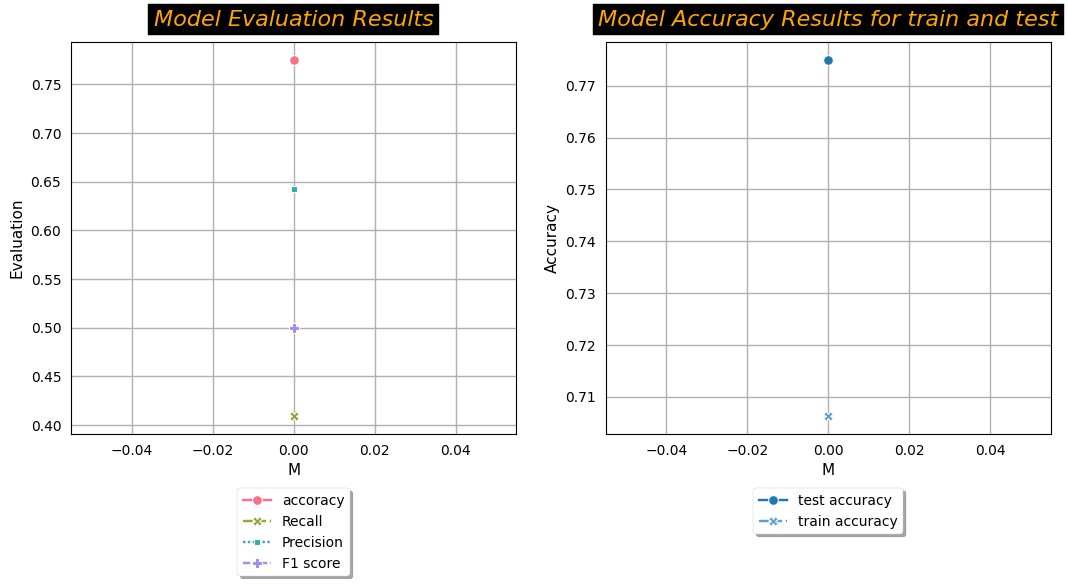

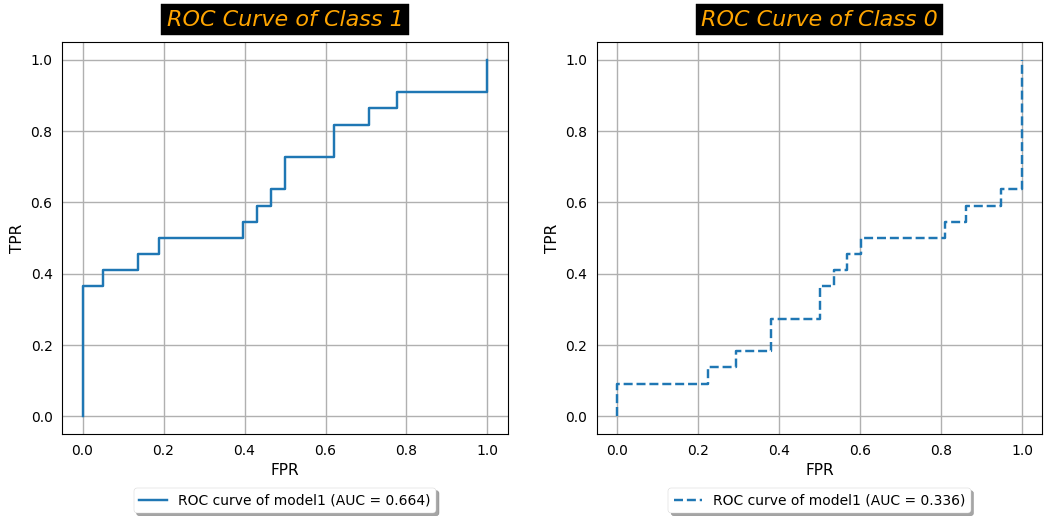

-------------------- Confusion Matrix --------------------
[[53  5]
 [13  9]]


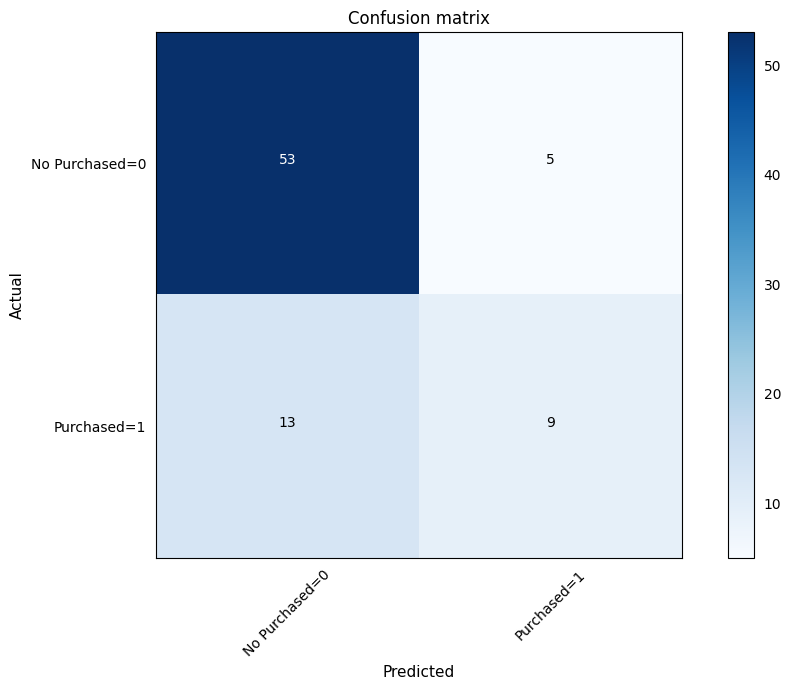

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.80      0.91      0.85        58
   Purchased=1       0.64      0.41      0.50        22

      accuracy                           0.78        80
     macro avg       0.72      0.66      0.68        80
  weighted avg       0.76      0.78      0.76        80
 

Jaccard Score: 0.3333333333333333 



In [67]:
# Now create first model
clf1, acc_test1, acc_train1 = modeling(x, y, 0.2, ['No Purchased=0', 'Purchased=1'])

Độ chính xác (Accuracy) đạt 0.78, đây không phải là kết quả tệ, nhưng chúng ta muốn cải thiện mô hình hơn nữa, vì vậy hãy tiếp tục.

###6. Cải thiện mô hình (Improve Model)

Đầu tiên hãy kiểm tra một số test_size để cải thiện mô hình

-------------------- Shape --------------------
x_train: (280, 3)
y_train: (280, 1)
x_test: (120, 3)
y_test: (120, 1)


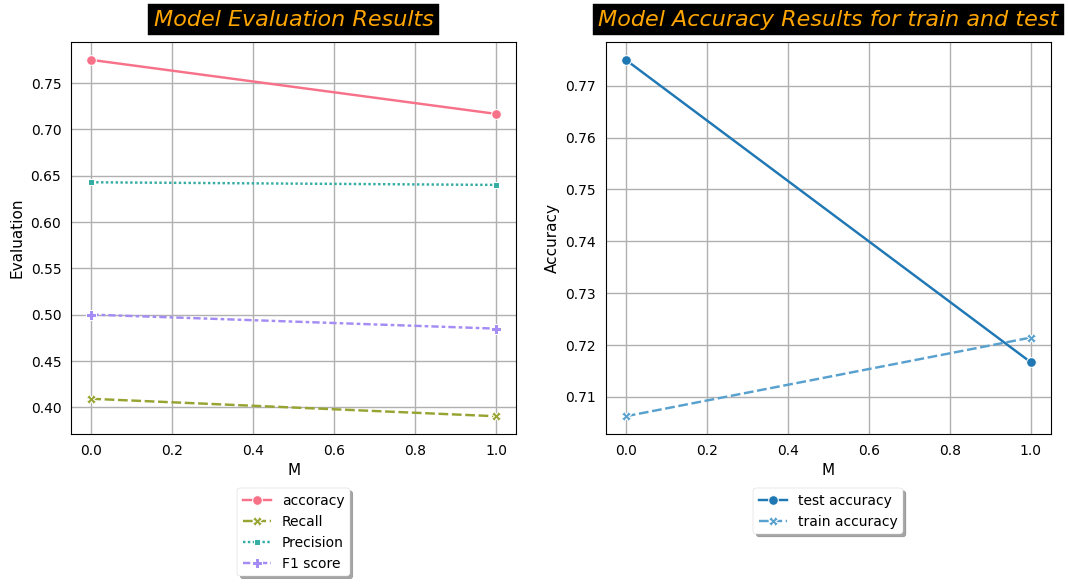

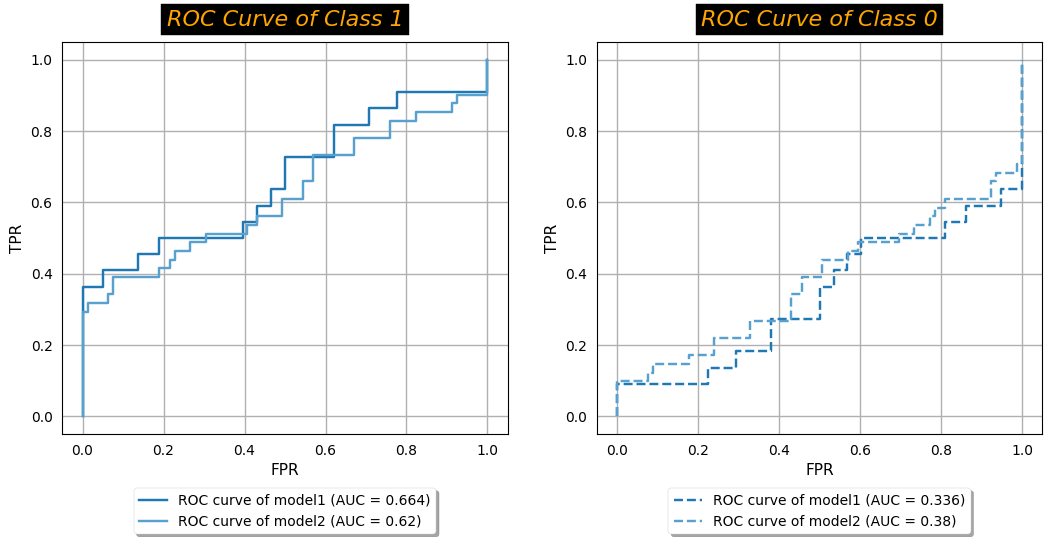

-------------------- Confusion Matrix --------------------
[[70  9]
 [25 16]]


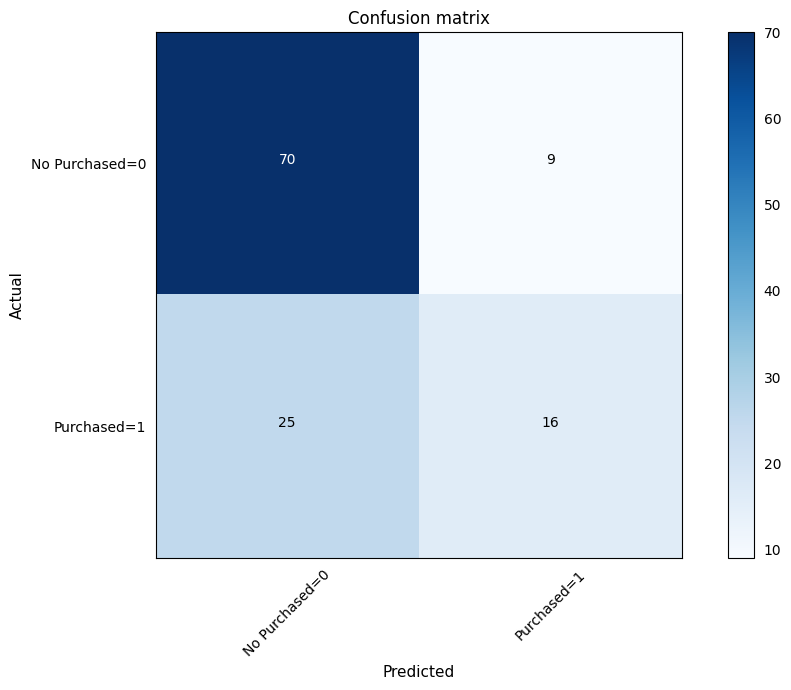

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.74      0.89      0.80        79
   Purchased=1       0.64      0.39      0.48        41

      accuracy                           0.72       120
     macro avg       0.69      0.64      0.64       120
  weighted avg       0.70      0.72      0.70       120
 

Jaccard Score: 0.32 



In [68]:
# test test_size= 0.3
clf2, acc_test2, acc_train2 = modeling(x, y, 0.3, ['No Purchased=0', 'Purchased=1'])

test_size = 0,3 không cải thiện hiệu suất của mô hình.

-------------------- Shape --------------------
x_train: (340, 3)
y_train: (340, 1)
x_test: (60, 3)
y_test: (60, 1)


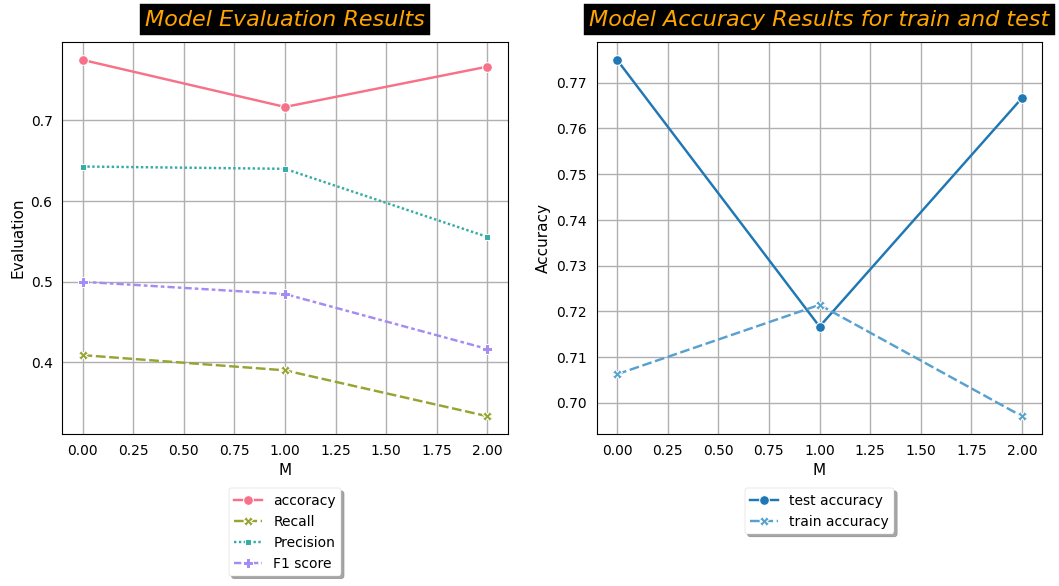

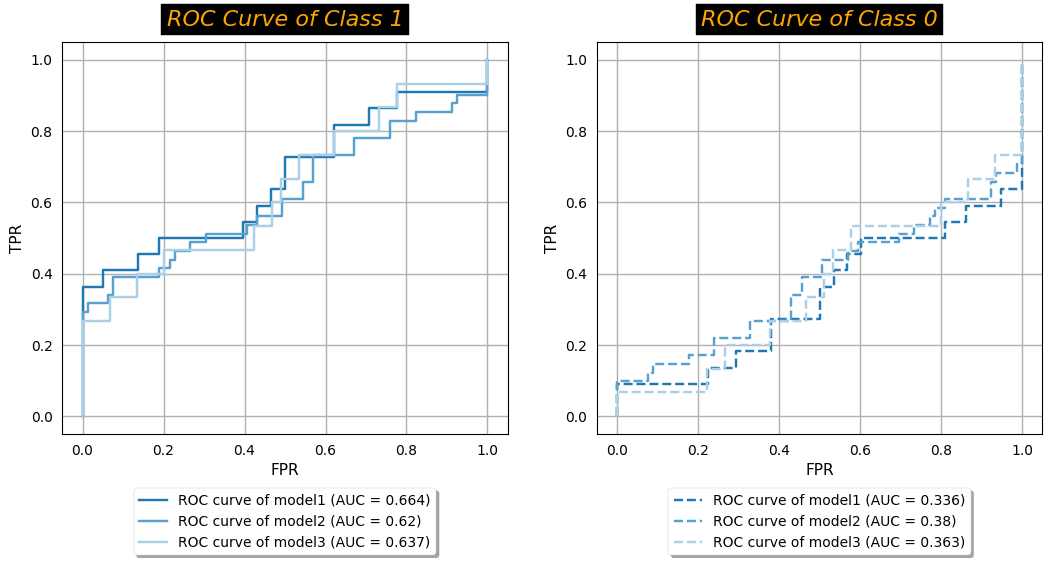

-------------------- Confusion Matrix --------------------
[[41  4]
 [10  5]]


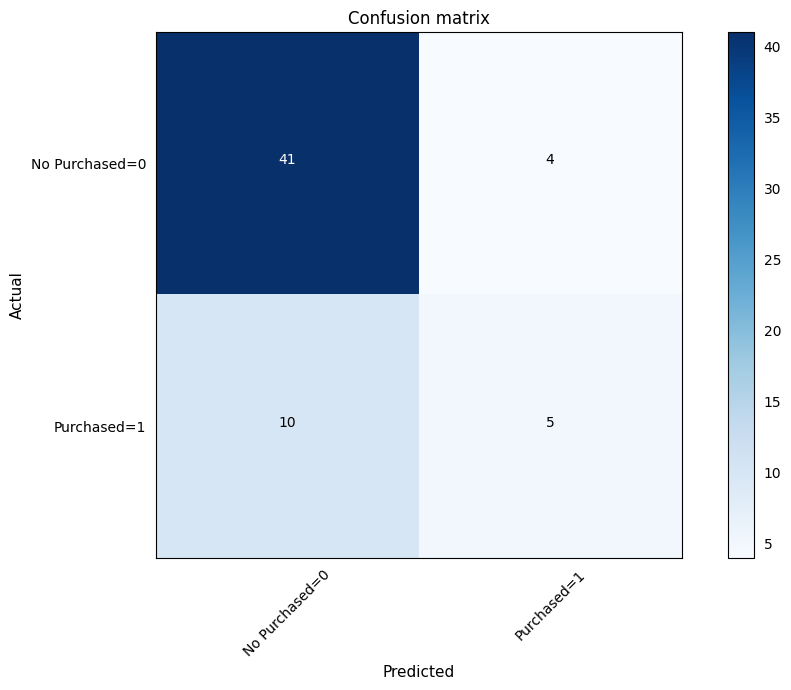

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.80      0.91      0.85        45
   Purchased=1       0.56      0.33      0.42        15

      accuracy                           0.77        60
     macro avg       0.68      0.62      0.64        60
  weighted avg       0.74      0.77      0.74        60
 

Jaccard Score: 0.2631578947368421 



In [69]:
# test test_size= 0.15
clf3, acc_test3, acc_train3 = modeling(x, y, 0.15, ['No Purchased=0', 'Purchased=1'])

test_size = 0,15 không cải thiện hiệu suất của mô hình.

-------------------- Shape --------------------
x_train: (360, 3)
y_train: (360, 1)
x_test: (40, 3)
y_test: (40, 1)


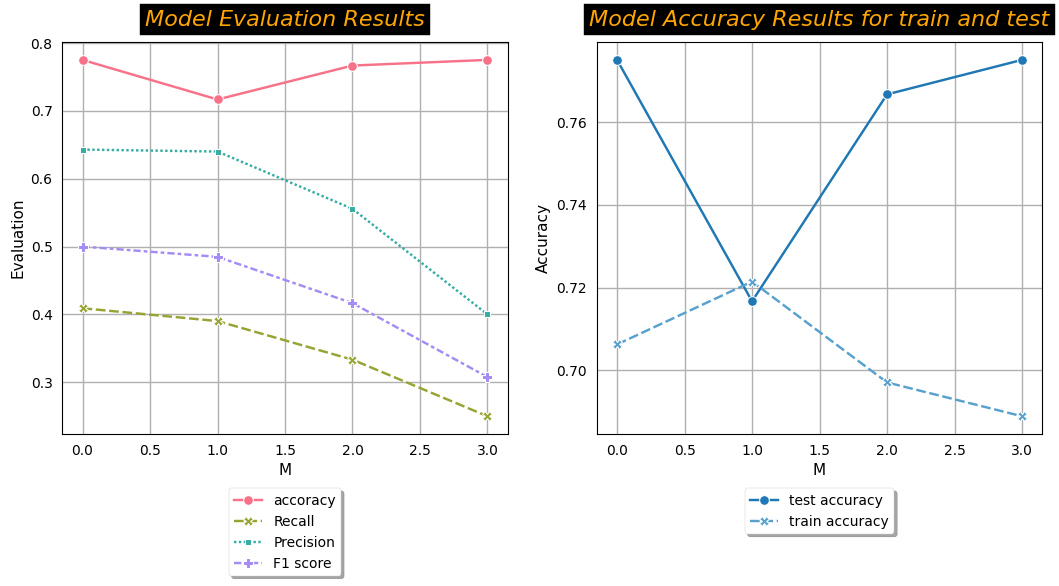

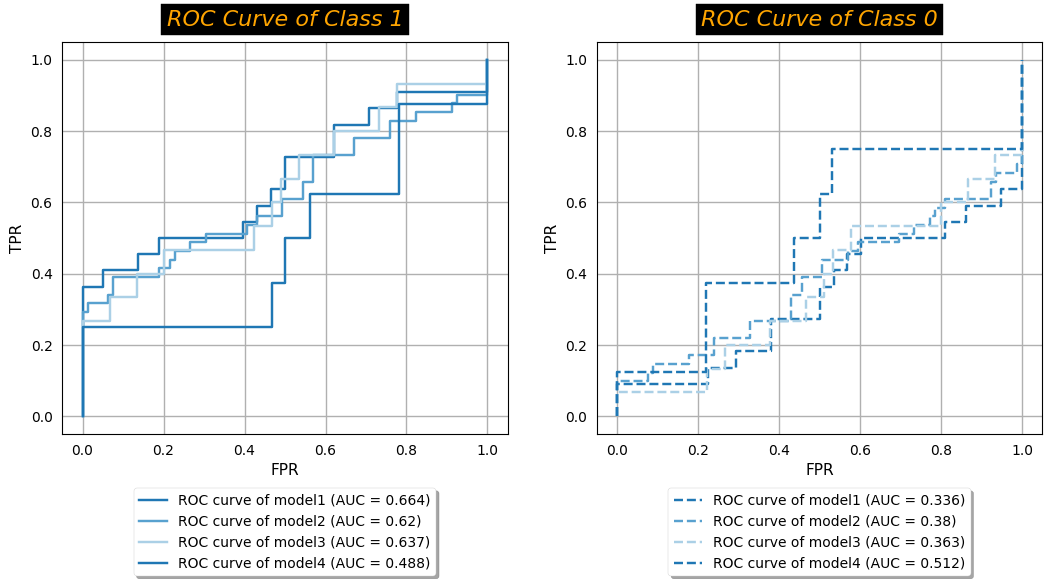

-------------------- Confusion Matrix --------------------
[[29  3]
 [ 6  2]]


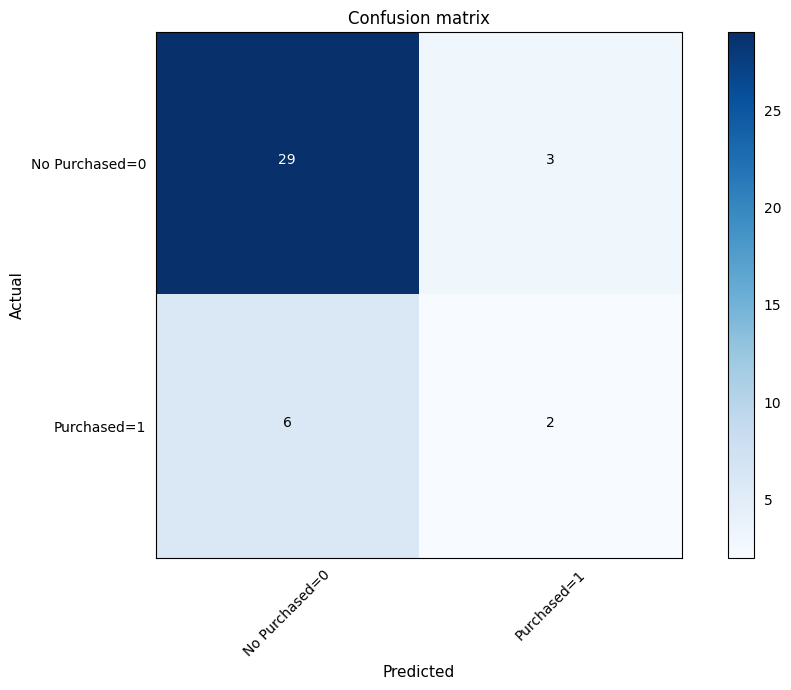

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.83      0.91      0.87        32
   Purchased=1       0.40      0.25      0.31         8

      accuracy                           0.78        40
     macro avg       0.61      0.58      0.59        40
  weighted avg       0.74      0.78      0.75        40
 

Jaccard Score: 0.18181818181818182 



In [70]:
# test test_size= 0.1
clf3, acc_test3, acc_train3 = modeling(x, y, 0.1, ['No Purchased=0', 'Purchased=1'])

test_size = 0,1 không cải thiện hiệu suất của mô hình. Vì vậy, chúng tôi xóa 3 kết quả cuối cùng vì chúng không cải thiện hiệu suất của mô hình.


In [71]:
# delete 3 last results
del FPR1[1:]
del TPR1[1:]
del FPR0[1:]
del TPR0[1:]
del ACC_test[1:]
del ACC_train[1:]
del Recall[1:]
del Precision[1:]
del F1[1:]

Được rồi. Vậy test_size=0.2 tốt hơn các tham số khác và việc chỉnh sửa siêu tham số này không làm thay đổi nhiều hiệu suất của mô hình. Bây giờ chúng ta thử cải thiện mô hình bằng cách Kiểm tra chéo với hàm Perform_cross_val.


In [72]:
Perform_cross_val(clf1, 10, x, y, scoring='accuracy')

-------------------- CV for k=10, scoring=accuracy --------------------
CV mean: 0.6399999999999999
CV results: [0.925 0.825 0.8   0.7   0.85  0.4   0.5   0.55  0.6   0.25 ]



Nếp gấp 6 và 10 khác biệt so với các nếp gấp khác. Do đó, có thể loại bỏ chúng đi, mô hình sẽ tốt hơn:


In [73]:
# first find index of datapoint in fold 1 and 3 by following func:
find_fold_index(10, x)

fold 1: [0,39]
--------------------
fold 2: [40,79]
--------------------
fold 3: [80,119]
--------------------
fold 4: [120,159]
--------------------
fold 5: [160,199]
--------------------
fold 6: [200,239]
--------------------
fold 7: [240,279]
--------------------
fold 8: [280,319]
--------------------
fold 9: [320,359]
--------------------
fold 10: [360,399]
--------------------


Bây giờ chúng ta xóa chỉ mục `[200-239] , [360-399]`

In [74]:
# delete above index from df2
df3 = df2.drop(df2.index[np.r_[200:239+1, 360:399+1]], axis=0)
print(f'df2:{df2.shape}')
print(f'df3:{df3.shape}')

df2:(400, 4)
df3:(320, 4)


In [75]:
# define new x and y
x2 = np.asanyarray(df3.drop('Purchased', axis=1))
y2 = df3.Purchased.values.reshape(-1,1)

-------------------- Shape --------------------
x_train: (256, 3)
y_train: (256, 1)
x_test: (64, 3)
y_test: (64, 1)


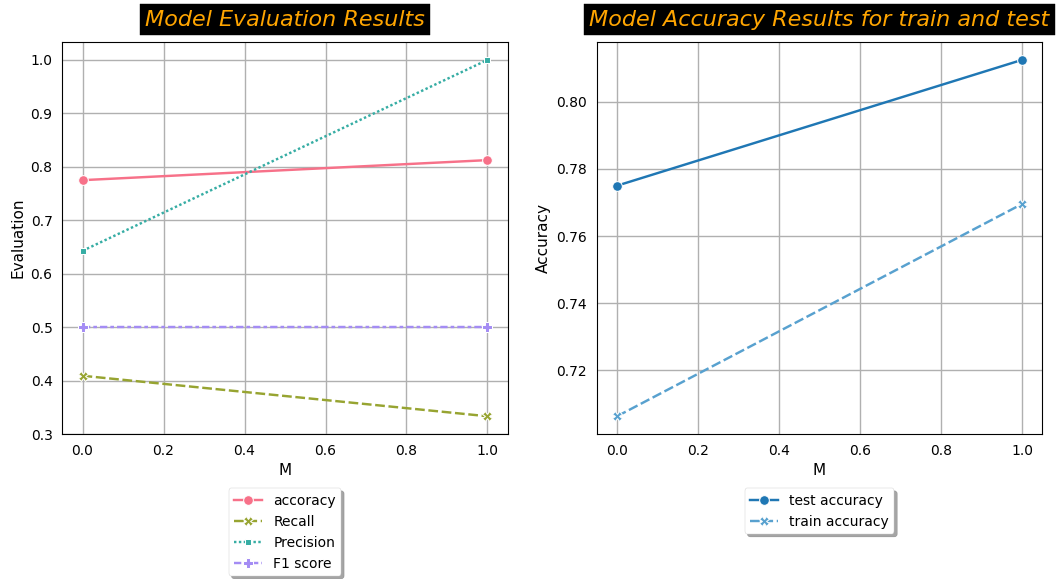

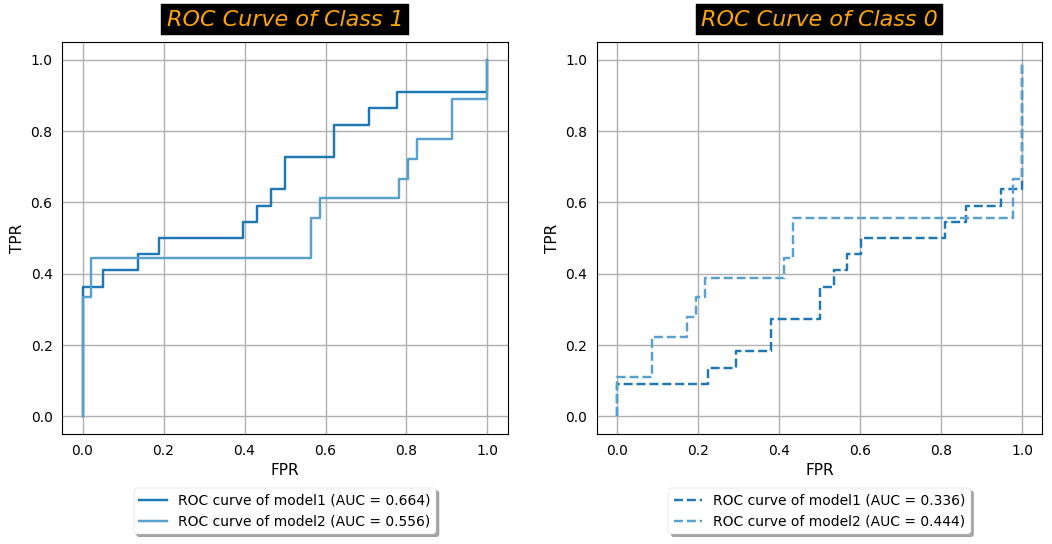

-------------------- Confusion Matrix --------------------
[[46  0]
 [12  6]]


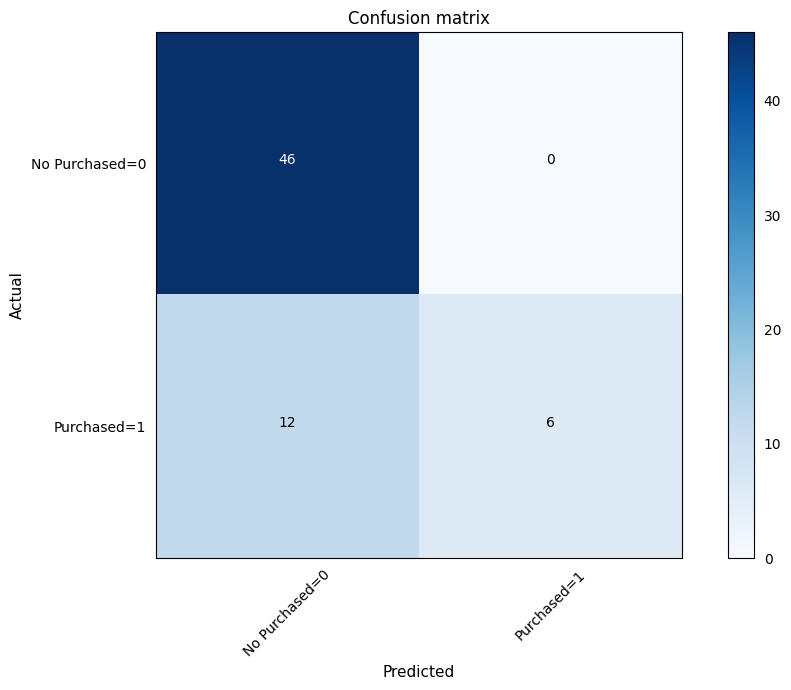

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.79      1.00      0.88        46
   Purchased=1       1.00      0.33      0.50        18

      accuracy                           0.81        64
     macro avg       0.90      0.67      0.69        64
  weighted avg       0.85      0.81      0.78        64
 

Jaccard Score: 0.3333333333333333 



In [76]:
clf2, acc_test2, acc_train2 = modeling(x2, y2, 0.2, classes=['No Purchased=0', 'Purchased=1'])

Hiện tại, hiệu suất của mô hình đã được cải thiện và đạt độ chính xác (accuracy) là 0.81.

Như thể hiện trong ma trận nhầm lẫn (confusion matrix) và báo cáo phân loại (classification report), do thiếu dữ liệu ở lớp 1, nên độ chính xác của lớp này khá thấp, và 12 người có quyết định mua sản phẩm đã bị dự đoán sai thành lớp 0.

Tuy nhiên, độ chính xác tổng thể mà mô hình đạt được vẫn được đánh giá là tốt.

###7. Trực quan hóa mô hình cuối cùng

In [82]:

pio.renderers.default = "colab"   # hoặc "notebook_connected"/"vscode" tùy môi trường

# giả sử bạn đã có X (features) và y (Purchased)
X_train, X_test, y_train, y_test = train_test_split(x2, y2, test_size=0.2, random_state=0)

# ghép y_test vào để vẽ
X_test = np.concatenate((X_test, y_test), axis=1)
X_test = pd.DataFrame(X_test, columns=['Gender','Age','EstimatedSalary','Purchased'])

# dự đoán màu theo mô hình clf2 đã fit
pred_color = clf2.predict(X_test.drop(columns='Purchased')).astype(str)

fig = px.scatter_3d(
    data_frame=X_test,
    x='Age', y='EstimatedSalary', z='Purchased',
    color=pred_color, color_discrete_map={'0':'red','1':'green'},
    opacity=0.6, height=700,
    title='Visualization Performance of clf2 in Predicting'
)

fig.show()

In [78]:
clf2.predict(x_test.drop('Purchased', axis=1))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

Trong hình minh họa phía trên, có thể thấy rõ rằng ở phần đáy của khối lập phương, nơi mà tất cả dữ liệu được dự đoán chính xác và tất cả các điểm đều có màu đỏ.

Tuy nhiên, ở phần trên của khối lập phương, nơi mà toàn bộ các điểm lẽ ra phải có màu xanh lá cây, vẫn xuất hiện một số điểm màu đỏ, điều này cho thấy các dự đoán sai.

###8. Dự đoán dữ liệu mẫu

In [79]:
# fit final model on all of data (train + test)
final_model = MultinomialNB()
final_model.fit(x2, y2)

# new sample data
new_sample = pd.DataFrame({'Gender': [1], 'Age': [18], 'EstimatedSalary': [70000]})
print(f"Gender: {new_sample['Gender'].values[0]}\n"
      f"Age: {new_sample['Age'].values[0]}\n"
      f"EstimatedSalary: {new_sample['EstimatedSalary'].values[0]}")

# Satandardize new_sample by use scaler
new_sample['EstimatedSalary'] = scaler.transform(new_sample[['EstimatedSalary']])
ns = np.asanyarray(new_sample)

# predict new sample data
result = final_model.predict(ns)
print('='*38)
print(f"class {result}")


Gender: 1
Age: 18
EstimatedSalary: 70000
class [0]


#Kết Thúc